In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
from pathlib import Path
import hashlib
import json
import torch

INPUT_ROOT = Path("/kaggle/input")

protocol_paths = list(
    INPUT_ROOT.rglob("E09_inputs/protocol.json")
)

assert len(protocol_paths) == 1, protocol_paths

E09_ROOT = protocol_paths[0].parent
manifest = json.loads(
    (E09_ROOT / "manifest.json").read_text()
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()

for item in manifest:
    path = E09_ROOT / item["file"]

    assert path.exists(), path
    assert path.stat().st_size == item["bytes"]
    assert sha256_file(path) == item["sha256"]

print("E09 root:", E09_ROOT)
print("File verificati:", len(manifest))
print("CUDA:", torch.cuda.is_available())
print("Numero GPU:", torch.cuda.device_count())

for index in range(torch.cuda.device_count()):
    print(index, torch.cuda.get_device_name(index))

print(
    "Clip:",
    E09_ROOT / "clip/san_donato_pilot_85_105.mp4",
)

E09 root: /kaggle/input/datasets/michelerais/thermal-thesis-e09-inputs/E09_inputs
File verificati: 34
CUDA: True
Numero GPU: 2
0 Tesla T4
1 Tesla T4
Clip: /kaggle/input/datasets/michelerais/thermal-thesis-e09-inputs/E09_inputs/clip/san_donato_pilot_85_105.mp4


In [2]:
%cd /kaggle/working

!test -d sam2 || git clone \
  https://github.com/facebookresearch/sam2.git

%cd /kaggle/working/sam2

!git checkout 2b90b9f5ceec907a1c18123530e92e794ad901a4
!pip install -q -e .

!mkdir -p checkpoints

!wget -q --show-progress \
  -O checkpoints/sam2.1_hiera_small.pt \
  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt

print("Commit SAM2:")
!git rev-parse HEAD

print("SHA-256 checkpoint:")
!sha256sum checkpoints/sam2.1_hiera_small.pt

/kaggle/working
Cloning into 'sam2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 1107 (delta 10), reused 4 (delta 4), pack-reused 1093 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 37.12 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/kaggle/working/sam2
Note: switching to '2b90b9f5ceec907a1c18123530e92e794ad901a4'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 2b90b9f remove `.pin_me

/kaggle/working/sam2


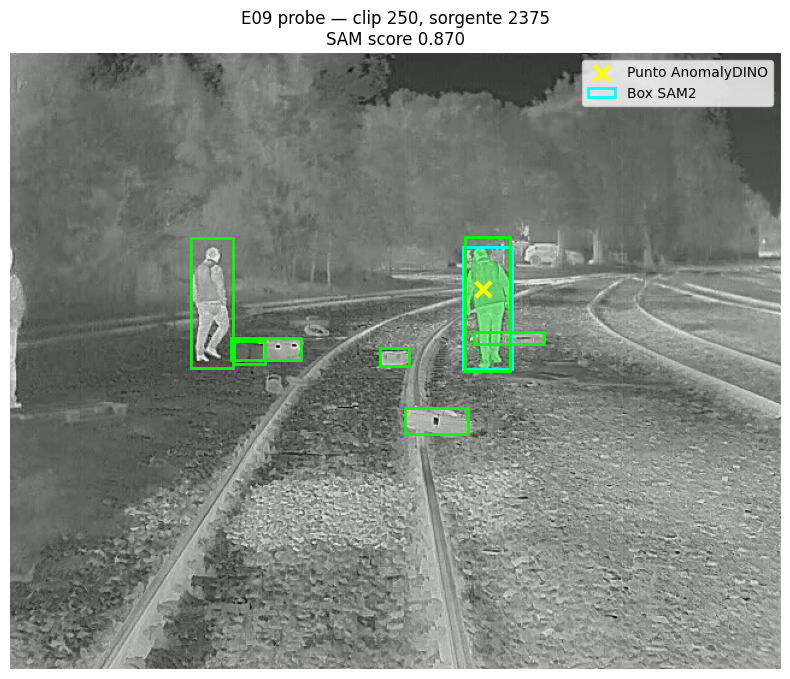

GPU: Tesla T4
Punto automatico: [[393.0, 196.0]]
Score delle tre maschere: [0.38284602761268616, 0.4517996907234192, 0.8700380921363831]
Box SAM2: (376, 161, 417, 262)
Area maschera: 2474
Box persona GT: 7


In [3]:
%cd /kaggle/working/sam2

from pathlib import Path
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from matplotlib.patches import Rectangle
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

E09_ROOT = list(
    Path("/kaggle/input").rglob("E09_inputs/protocol.json")
)[0].parent

checkpoint = (
    Path("/kaggle/working/sam2")
    / "checkpoints/sam2.1_hiera_small.pt"
)

model_config = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_model = build_sam2(
    model_config,
    str(checkpoint),
    device="cuda",
)

predictor = SAM2ImagePredictor(sam2_model)

anomaly_manifest = pd.read_csv(
    E09_ROOT / "manifests/E09_anomaly_manifest.csv"
)

ground_truth = pd.read_csv(
    E09_ROOT / "annotations/visible_ground_truth_clip.csv"
)

# Frame di controllo
clip_frame = 250
row = anomaly_manifest[
    anomaly_manifest["clip_frame"] == clip_frame
].iloc[0]

capture = cv2.VideoCapture(
    str(E09_ROOT / "clip/san_donato_pilot_85_105.mp4")
)
capture.set(cv2.CAP_PROP_POS_FRAMES, clip_frame)
ok, frame_bgr = capture.read()
capture.release()

assert ok

frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB,
)

point = np.array(
    [[row["max_x"], row["max_y"]]],
    dtype=np.float32,
)
point_label = np.array([1], dtype=np.int32)

with torch.inference_mode():
    predictor.set_image(frame_rgb)

    masks, sam_scores, logits = predictor.predict(
        point_coords=point,
        point_labels=point_label,
        multimask_output=True,
    )

best_index = int(np.argmax(sam_scores))
best_mask = masks[best_index].astype(bool)

ys, xs = np.where(best_mask)

sam_box = (
    int(xs.min()),
    int(ys.min()),
    int(xs.max()),
    int(ys.max()),
)

fig, axis = plt.subplots(figsize=(10, 8))
axis.imshow(frame_rgb)

overlay = np.zeros(
    (*best_mask.shape, 4),
    dtype=np.float32,
)
overlay[best_mask] = [0.1, 1.0, 0.2, 0.45]
axis.imshow(overlay)

axis.scatter(
    point[0, 0],
    point[0, 1],
    c="yellow",
    marker="x",
    s=120,
    linewidths=3,
    label="Punto AnomalyDINO",
)

axis.add_patch(
    Rectangle(
        (sam_box[0], sam_box[1]),
        sam_box[2] - sam_box[0],
        sam_box[3] - sam_box[1],
        fill=False,
        edgecolor="cyan",
        linewidth=2,
        label="Box SAM2",
    )
)

gt_frame = ground_truth[
    (ground_truth["frame"] == int(row["source_frame"]))
    & (ground_truth["tipo"] == "persona")
    & (ground_truth["outside"] == 0)
]

for index, gt in gt_frame.iterrows():
    axis.add_patch(
        Rectangle(
            (gt["xtl"], gt["ytl"]),
            gt["xbr"] - gt["xtl"],
            gt["ybr"] - gt["ytl"],
            fill=False,
            edgecolor="lime",
            linewidth=2,
        )
    )

axis.set_title(
    f"E09 probe — clip {clip_frame}, sorgente {int(row['source_frame'])}\n"
    f"SAM score {sam_scores[best_index]:.3f}"
)
axis.axis("off")
axis.legend()
plt.show()

print("GPU:", torch.cuda.get_device_name(0))
print("Punto automatico:", point.tolist())
print("Score delle tre maschere:", sam_scores.tolist())
print("Box SAM2:", sam_box)
print("Area maschera:", int(best_mask.sum()))
print("Box persona GT:", len(gt_frame))

In [4]:
from pathlib import Path
from IPython.display import FileLink, display
from tqdm.auto import tqdm
import cv2
import hashlib
import json
import shutil
import time
import zipfile
import numpy as np
import pandas as pd
import torch

WORK = Path("/kaggle/working")

anomaly_manifest = pd.read_csv(
    E09_ROOT / "manifests/E09_anomaly_manifest.csv"
).sort_values("clip_frame")

normal_manifest = pd.read_csv(
    E09_ROOT / "manifests/E09_normal_test_manifest.csv"
)

baseline = pd.read_csv(
    E09_ROOT
    / "manifests/E09_baseline_component_per_frame.csv"
)

ground_truth = pd.read_csv(
    E09_ROOT / "annotations/visible_ground_truth_clip.csv"
)

ground_truth = ground_truth[
    (ground_truth["tipo"] == "persona")
    & (ground_truth["outside"] == 0)
].copy()

with np.load(
    E09_ROOT / "anomalydino/raw_anomaly_maps_safe.npz",
    allow_pickle=False,
) as archive:
    raw_maps = archive["maps"].copy()

def box_iou(first, second):
    x1 = max(first[0], second[0])
    y1 = max(first[1], second[1])
    x2 = min(first[2], second[2])
    y2 = min(first[3], second[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    first_area = max(0, first[2] - first[0]) * max(
        0, first[3] - first[1]
    )
    second_area = max(0, second[2] - second[0]) * max(
        0, second[3] - second[1]
    )

    union = first_area + second_area - intersection
    return intersection / union if union else 0.0

def mask_to_box(mask):
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return None

    return (
        int(xs.min()),
        int(ys.min()),
        int(xs.max()) + 1,
        int(ys.max()) + 1,
    )

def predict_mask(image_rgb, point_x, point_y):
    point = np.array(
        [[point_x, point_y]],
        dtype=np.float32,
    )
    labels = np.array([1], dtype=np.int32)

    with torch.inference_mode():
        predictor.set_image(image_rgb)

        masks, scores, _ = predictor.predict(
            point_coords=point,
            point_labels=labels,
            multimask_output=True,
        )

    best_index = int(np.argmax(scores))

    return (
        masks[best_index].astype(bool),
        float(scores[best_index]),
    )

# Inferenza sui 500 frame anomali
capture = cv2.VideoCapture(
    str(E09_ROOT / "clip/san_donato_pilot_85_105.mp4")
)

anomaly_rows = []
packed_anomaly_masks = []

torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()
start_time = time.time()

for row in tqdm(
    anomaly_manifest.itertuples(index=False),
    total=len(anomaly_manifest),
    desc="E09 SAM2 — frame anomali",
):
    ok, frame_bgr = capture.read()
    assert ok, row.clip_frame

    frame_rgb = cv2.cvtColor(
        frame_bgr,
        cv2.COLOR_BGR2RGB,
    )

    mask, sam_score = predict_mask(
        frame_rgb,
        row.max_x,
        row.max_y,
    )

    sam_box = mask_to_box(mask)

    gt_frame = ground_truth[
        ground_truth["frame"] == row.source_frame
    ]

    best_iou = 0.0
    best_track_id = -1

    if sam_box is not None:
        for gt in gt_frame.itertuples():
            current_iou = box_iou(
                sam_box,
                (gt.xtl, gt.ytl, gt.xbr, gt.ybr),
            )

            if current_iou > best_iou:
                best_iou = current_iou
                best_track_id = int(gt.track_id)

    anomaly_rows.append({
        "source_frame": int(row.source_frame),
        "clip_frame": int(row.clip_frame),
        "point_x": float(row.max_x),
        "point_y": float(row.max_y),
        "point_hit_person": int(row.hit_person),
        "sam_score": sam_score,
        "mask_area": int(mask.sum()),
        "sam_xtl": sam_box[0] if sam_box else np.nan,
        "sam_ytl": sam_box[1] if sam_box else np.nan,
        "sam_xbr": sam_box[2] if sam_box else np.nan,
        "sam_ybr": sam_box[3] if sam_box else np.nan,
        "best_person_iou": best_iou,
        "best_person_track_id": best_track_id,
        "person_gt_boxes": len(gt_frame),
    })

    packed_anomaly_masks.append(
        np.packbits(mask.reshape(-1))
    )

capture.release()

# Controllo sui 20 frame normali:
# SAM2 viene eseguito soltanto sui 4 falsi positivi E05.
normal_rows = []
packed_normal_masks = []
empty_packed = np.zeros(
    (512 * 640 + 7) // 8,
    dtype=np.uint8,
)

for row in tqdm(
    normal_manifest.itertuples(index=False),
    total=len(normal_manifest),
    desc="E09 SAM2 — controllo normale",
):
    executed = int(row.predicted_anomaly) == 1

    if executed:
        image_path = E09_ROOT / row.image_relative_path
        frame_bgr = cv2.imread(str(image_path))
        assert frame_bgr is not None, image_path

        frame_rgb = cv2.cvtColor(
            frame_bgr,
            cv2.COLOR_BGR2RGB,
        )

        anomaly_map = raw_maps[int(row.npz_index)]
        resized_map = cv2.resize(
            anomaly_map,
            (640, 512),
            interpolation=cv2.INTER_LINEAR,
        )

        point_y, point_x = np.unravel_index(
            np.argmax(resized_map),
            resized_map.shape,
        )

        mask, sam_score = predict_mask(
            frame_rgb,
            point_x,
            point_y,
        )
        sam_box = mask_to_box(mask)
        packed_normal_masks.append(
            np.packbits(mask.reshape(-1))
        )

    else:
        point_x = np.nan
        point_y = np.nan
        sam_score = np.nan
        sam_box = None
        mask = np.zeros((512, 640), dtype=bool)
        packed_normal_masks.append(empty_packed.copy())

    normal_rows.append({
        "filename": row.filename,
        "source_frame": int(row.source_frame),
        "anomaly_score": float(row.anomaly_score),
        "frame_prediction": int(row.predicted_anomaly),
        "sam_executed": int(executed),
        "point_x": point_x,
        "point_y": point_y,
        "sam_score": sam_score,
        "mask_area": int(mask.sum()),
        "sam_xtl": sam_box[0] if sam_box else np.nan,
        "sam_ytl": sam_box[1] if sam_box else np.nan,
        "sam_xbr": sam_box[2] if sam_box else np.nan,
        "sam_ybr": sam_box[3] if sam_box else np.nan,
    })

torch.cuda.synchronize()
inference_seconds = time.time() - start_time

anomaly_results = pd.DataFrame(anomaly_rows)
normal_results = pd.DataFrame(normal_rows)

# Confronto con la componente AnomalyDINO contenente il punto
comparison = anomaly_results.merge(
    baseline[
        [
            "source_frame",
            "best_person_iou",
            "point_hit_person",
        ]
    ],
    on="source_frame",
    suffixes=("_sam2", "_anomalydino"),
    validate="one_to_one",
)

comparison["iou_delta_sam2_minus_anomalydino"] = (
    comparison["best_person_iou_sam2"]
    - comparison["best_person_iou_anomalydino"]
)

def summary_row(method, values, scope):
    values = np.asarray(values, dtype=float)

    return {
        "method": method,
        "scope": scope,
        "frames": len(values),
        "mean_iou": float(values.mean()),
        "median_iou": float(np.median(values)),
        "hits_iou_0_3": int(np.sum(values >= 0.3)),
        "hit_rate_iou_0_3": float(np.mean(values >= 0.3)),
        "hits_iou_0_5": int(np.sum(values >= 0.5)),
        "hit_rate_iou_0_5": float(np.mean(values >= 0.5)),
    }

point_hit = comparison["point_hit_person_sam2"] == 1

comparison_summary = pd.DataFrame([
    summary_row(
        "anomalydino_max_component",
        comparison["best_person_iou_anomalydino"],
        "all_500_frames",
    ),
    summary_row(
        "sam2_positive_point",
        comparison["best_person_iou_sam2"],
        "all_500_frames",
    ),
    summary_row(
        "anomalydino_max_component",
        comparison.loc[
            point_hit,
            "best_person_iou_anomalydino",
        ],
        "point_hits_person",
    ),
    summary_row(
        "sam2_positive_point",
        comparison.loc[
            point_hit,
            "best_person_iou_sam2",
        ],
        "point_hits_person",
    ),
])

total_gt_boxes = len(ground_truth)
detection_rows = []

for method, column in [
    (
        "anomalydino_max_component",
        "best_person_iou_anomalydino",
    ),
    (
        "sam2_positive_point",
        "best_person_iou_sam2",
    ),
]:
    for threshold in [0.3, 0.5]:
        true_positives = int(
            np.sum(comparison[column] >= threshold)
        )
        false_positives = 500 - true_positives
        false_negatives = total_gt_boxes - true_positives

        precision = true_positives / 500
        recall = true_positives / total_gt_boxes
        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall
            else 0.0
        )

        detection_rows.append({
            "method": method,
            "iou_threshold": threshold,
            "predictions": 500,
            "gt_person_boxes": total_gt_boxes,
            "tp": true_positives,
            "fp": false_positives,
            "fn": false_negatives,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

detection_summary = pd.DataFrame(detection_rows)

anomaly_results.to_csv(
    WORK / "E09_sam2_anomaly_per_frame.csv",
    index=False,
)
normal_results.to_csv(
    WORK / "E09_sam2_normal_control.csv",
    index=False,
)
comparison.to_csv(
    WORK / "E09_per_frame_comparison.csv",
    index=False,
)
comparison_summary.to_csv(
    WORK / "E09_comparison_summary.csv",
    index=False,
)
detection_summary.to_csv(
    WORK / "E09_detection_summary.csv",
    index=False,
)

np.savez_compressed(
    WORK / "E09_sam2_masks_packbits.npz",
    anomaly_masks=np.stack(
        packed_anomaly_masks
    ).astype(np.uint8),
    anomaly_source_frames=anomaly_results[
        "source_frame"
    ].to_numpy(dtype=np.int16),
    normal_masks=np.stack(
        packed_normal_masks
    ).astype(np.uint8),
    normal_executed=normal_results[
        "sam_executed"
    ].to_numpy(dtype=np.int8),
    mask_shape=np.array([512, 640], dtype=np.int16),
)

metadata = {
    "experiment_id": "E09_v1_anomalydino_point_sam2",
    "frames_anomaly": 500,
    "frames_normal_control": 20,
    "normal_frames_passing_gate": int(
        normal_results["sam_executed"].sum()
    ),
    "inference_seconds": inference_seconds,
    "processed_sam_masks": int(
        500 + normal_results["sam_executed"].sum()
    ),
    "sam_masks_per_second": (
        500 + normal_results["sam_executed"].sum()
    ) / inference_seconds,
    "peak_gpu_gb": (
        torch.cuda.max_memory_allocated() / 1024**3
    ),
    "sam2_commit":
        "2b90b9f5ceec907a1c18123530e92e794ad901a4",
    "sam2_checkpoint_sha256":
        "6d1aa6f30de5c92224f8172114de081d104bbd23dd9dc5c58996f0cad5dc4d38",
    "anomalydino_source": "E05_v1_anomalydino_16shot",
    "frame_threshold": 0.28902236819267274,
    "multimask_selection": "highest predicted IoU",
    "fine_tuning": False,
    "improved_frames": int(
        (
            comparison[
                "iou_delta_sam2_minus_anomalydino"
            ] > 0
        ).sum()
    ),
    "mean_iou_delta": float(
        comparison[
            "iou_delta_sam2_minus_anomalydino"
        ].mean()
    ),
}

with open(
    WORK / "E09_base_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(metadata, file, indent=2)

# ZIP immediato di sicurezza
bundle = WORK / "E09_base_checkpoint"

if bundle.exists():
    shutil.rmtree(bundle)

bundle.mkdir()

files_to_save = [
    "E09_sam2_anomaly_per_frame.csv",
    "E09_sam2_normal_control.csv",
    "E09_per_frame_comparison.csv",
    "E09_comparison_summary.csv",
    "E09_detection_summary.csv",
    "E09_sam2_masks_packbits.npz",
    "E09_base_metadata.json",
]

for filename in files_to_save:
    shutil.copy2(
        WORK / filename,
        bundle / filename,
    )

shutil.copy2(
    E09_ROOT / "protocol.json",
    bundle / "protocol.json",
)

zip_path = WORK / "E09_base_checkpoint.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for path in sorted(bundle.iterdir()):
        archive.write(
            path,
            arcname=f"E09_base_checkpoint/{path.name}",
        )

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()

print("Tempo:", round(inference_seconds, 2), "s")
print("Picco GPU:", round(metadata["peak_gpu_gb"], 2), "GB")
print("Frame migliorati da SAM2:", metadata["improved_frames"])
print("Delta IoU medio:", round(metadata["mean_iou_delta"], 4))

print("\nRiepilogo:")
display(comparison_summary)

print("\nMetriche detection:")
display(detection_summary)

print("\nZIP:", zip_path)
print("SHA-256:", sha256_file(zip_path))
display(FileLink(str(zip_path)))

E09 SAM2 — frame anomali:   0%|          | 0/500 [00:00<?, ?it/s]

E09 SAM2 — controllo normale:   0%|          | 0/20 [00:00<?, ?it/s]

Tempo: 98.02 s
Picco GPU: 0.61 GB
Frame migliorati da SAM2: 457
Delta IoU medio: 0.2153

Riepilogo:


,method,scope,frames,mean_iou,median_iou,hits_iou_0_3,hit_rate_iou_0_3,hits_iou_0_5,hit_rate_iou_0_5
0,anomalydino_max_component,all_500_frames,500,0.501247,0.506445,464,0.928000,267,0.534000
1,sam2_positive_point,all_500_frames,500,0.716535,0.756963,488,0.976000,467,0.934000
2,anomalydino_max_component,point_hits_person,478,0.506998,0.508544,449,0.939331,259,0.541841
3,sam2_positive_point,point_hits_person,478,0.720476,0.755251,473,0.989540,452,0.945607



Metriche detection:


,method,iou_threshold,predictions,gt_person_boxes,tp,fp,fn,precision,recall,f1
0,anomalydino_max_component,0.3,500,3732,464,36,3268,0.928,0.124330,0.219282
1,anomalydino_max_component,0.5,500,3732,267,233,3465,0.534,0.071543,0.126181
2,sam2_positive_point,0.3,500,3732,488,12,3244,0.976,0.130761,0.230624
3,sam2_positive_point,0.5,500,3732,467,33,3265,0.934,0.125134,0.220699



ZIP: /kaggle/working/E09_base_checkpoint.zip
SHA-256: f4a4f9f1d3f642381ef2669b747f0e28d896ba95004078cf26691d7f85dcb053


/kaggle/working/E09_base_checkpoint.zip

In [5]:
!ls -lh /kaggle/working/E09_base_checkpoint.zip
!unzip -t /kaggle/working/E09_base_checkpoint.zip
!unzip -l /kaggle/working/E09_base_checkpoint.zip

-rw-r--r-- 1 root root 128K Jul  6 00:31 /kaggle/working/E09_base_checkpoint.zip
Archive:  /kaggle/working/E09_base_checkpoint.zip
    testing: E09_base_checkpoint/E09_base_metadata.json   OK
    testing: E09_base_checkpoint/E09_comparison_summary.csv   OK
    testing: E09_base_checkpoint/E09_detection_summary.csv   OK
    testing: E09_base_checkpoint/E09_per_frame_comparison.csv   OK
    testing: E09_base_checkpoint/E09_sam2_anomaly_per_frame.csv   OK
    testing: E09_base_checkpoint/E09_sam2_masks_packbits.npz   OK
    testing: E09_base_checkpoint/E09_sam2_normal_control.csv   OK
    testing: E09_base_checkpoint/protocol.json   OK
No errors detected in compressed data of /kaggle/working/E09_base_checkpoint.zip.
Archive:  /kaggle/working/E09_base_checkpoint.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
      689  2026-07-06 00:31   E09_base_checkpoint/E09_base_metadata.json
      554  2026-07-06 00:31   E09_base_checkpoint/E09_comparison_summary.csv
      4